<h1><b>AUTISM DETECTION USING MACHINE LEARNING</b></h1>

<center><img src="https://www.kailashmantry.net/wp-content/uploads/2021/01/signs-of-autism.jpg" width="700"></center>

##**1. IMPORTING PACKAGES**

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

##**2. UPLOADING DATASET**

In [4]:
autism_data=pd.read_csv("autism.csv")

##**3. DATAPREPROCESSING**

###**a. Describing the data**

In [5]:
autism_data.head()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,Global developmental delay/intellectual disability,Social/Behavioural Issues,Childhood Autism Rating Scale,Anxiety_disorder,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who_completed_the_test,ASD_traits
0,1,0,0,0,0,0,0,1,1,0,...,Yes,Yes,1,Yes,F,middle eastern,Yes,No,Family Member,No
1,2,1,1,0,0,0,1,1,0,0,...,Yes,Yes,2,Yes,M,White European,Yes,No,Family Member,Yes
2,3,1,0,0,0,0,0,1,1,0,...,Yes,Yes,4,Yes,M,Middle Eastern,Yes,No,Family Member,Yes
3,4,1,1,1,1,1,1,1,1,1,...,Yes,Yes,2,Yes,M,Hispanic,No,No,Family Member,Yes
4,5,1,1,0,1,1,1,1,1,1,...,Yes,Yes,1,Yes,F,White European,No,No,Family Member,Yes


In [6]:
autism_data.shape

(1985, 28)

In [7]:
autism_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1985 entries, 0 to 1984
Data columns (total 28 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   CASE_NO_PATIENT'S                                   1985 non-null   int64  
 1   A1                                                  1985 non-null   int64  
 2   A2                                                  1985 non-null   int64  
 3   A3                                                  1985 non-null   int64  
 4   A4                                                  1985 non-null   int64  
 5   A5                                                  1985 non-null   int64  
 6   A6                                                  1985 non-null   int64  
 7   A7                                                  1985 non-null   int64  
 8   A8                                                  1985 non-null   int64  
 9

In [8]:
autism_data.describe()

,CASE_NO_PATIENT'S,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10_Autism_Spectrum_Quotient,Social_Responsiveness_Scale,Age_Years,Qchat_10_Score,Childhood Autism Rating Scale
count,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1985.000000,1976.000000,1985.000000,1946.000000,1985.000000
mean,993.000000,0.299244,0.238287,0.213098,0.272040,0.278589,0.306297,0.345088,0.243829,0.259950,0.446348,3.074393,9.624685,4.234841,1.701763
std,573.164462,0.458042,0.426143,0.409600,0.445123,0.448418,0.461071,0.475517,0.429499,0.438717,0.497238,3.680263,4.302416,2.898247,1.015367
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,497.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,2.000000,1.000000
50%,993.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,9.000000,4.000000,1.000000
75%,1489.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,5.000000,14.000000,6.000000,2.000000
max,1985.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10.000000,18.000000,10.000000,4.000000


###**b. Data Cleaning**
Removing irrelavant columns

In [9]:
autism_data=autism_data.drop(['CASE_NO_PATIENT\'S', 'A1','A2','A3','A4','A5','A6','A7','A8','A9','A10_Autism_Spectrum_Quotient','Ethnicity','Who_completed_the_test','Childhood Autism Rating Scale'], axis=1)
autism_data

,Social_Responsiveness_Scale,Age_Years,Qchat_10_Score,Speech Delay/Language Disorder,Learning disorder,Genetic_Disorders,Depression,Global developmental delay/intellectual disability,Social/Behavioural Issues,Anxiety_disorder,Sex,Jaundice,Family_mem_with_ASD,ASD_traits
0,3.0,2,3.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,F,Yes,No,No
1,6.0,3,4.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,M,Yes,No,Yes
2,7.0,3,4.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,M,Yes,No,Yes
3,1.0,2,10.0,Yes,Yes,No,Yes,Yes,Yes,Yes,M,No,No,Yes
4,3.0,2,9.0,Yes,Yes,No,Yes,Yes,Yes,Yes,F,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,1.0,7,6.0,No,No,No,No,No,No,No,M,No,No,No
1981,0.0,14,0.0,No,No,No,No,No,No,No,F,No,No,No
1982,1.0,7,6.0,No,No,No,No,No,No,No,M,No,No,Yes
1983,0.0,14,0.0,No,No,No,No,No,No,No,M,No,No,No


###**c. Handling Null Values**

In [10]:
autism_data.isnull().sum()

Social_Responsiveness_Scale                            9
Age_Years                                              0
Qchat_10_Score                                        39
Speech Delay/Language Disorder                         0
Learning disorder                                      0
Genetic_Disorders                                      0
Depression                                             1
Global developmental delay/intellectual disability     0
Social/Behavioural Issues                             14
Anxiety_disorder                                       0
Sex                                                    0
Jaundice                                               0
Family_mem_with_ASD                                    0
ASD_traits                                             0
dtype: int64

In [11]:
autism_data["Social_Responsiveness_Scale"]=autism_data["Social_Responsiveness_Scale"].fillna(0)

In [12]:
autism_data["Qchat_10_Score"]=autism_data["Qchat_10_Score"].fillna(0)

In [13]:
autism_data=autism_data.dropna()
autism_data

,Social_Responsiveness_Scale,Age_Years,Qchat_10_Score,Speech Delay/Language Disorder,Learning disorder,Genetic_Disorders,Depression,Global developmental delay/intellectual disability,Social/Behavioural Issues,Anxiety_disorder,Sex,Jaundice,Family_mem_with_ASD,ASD_traits
0,3.0,2,3.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,F,Yes,No,No
1,6.0,3,4.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,M,Yes,No,Yes
2,7.0,3,4.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,M,Yes,No,Yes
3,1.0,2,10.0,Yes,Yes,No,Yes,Yes,Yes,Yes,M,No,No,Yes
4,3.0,2,9.0,Yes,Yes,No,Yes,Yes,Yes,Yes,F,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,1.0,7,6.0,No,No,No,No,No,No,No,M,No,No,No
1981,0.0,14,0.0,No,No,No,No,No,No,No,F,No,No,No
1982,1.0,7,6.0,No,No,No,No,No,No,No,M,No,No,Yes
1983,0.0,14,0.0,No,No,No,No,No,No,No,M,No,No,No


In [14]:
autism_data.isnull().sum()

Social_Responsiveness_Scale                           0
Age_Years                                             0
Qchat_10_Score                                        0
Speech Delay/Language Disorder                        0
Learning disorder                                     0
Genetic_Disorders                                     0
Depression                                            0
Global developmental delay/intellectual disability    0
Social/Behavioural Issues                             0
Anxiety_disorder                                      0
Sex                                                   0
Jaundice                                              0
Family_mem_with_ASD                                   0
ASD_traits                                            0
dtype: int64

In [15]:
autism_data = autism_data.astype({"Social_Responsiveness_Scale": 'int', "Qchat_10_Score": 'int'})

In [16]:
autism_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1970 entries, 0 to 1984
Data columns (total 14 columns):
 #   Column                                              Non-Null Count  Dtype 
---  ------                                              --------------  ----- 
 0   Social_Responsiveness_Scale                         1970 non-null   int64 
 1   Age_Years                                           1970 non-null   int64 
 2   Qchat_10_Score                                      1970 non-null   int64 
 3   Speech Delay/Language Disorder                      1970 non-null   object
 4   Learning disorder                                   1970 non-null   object
 5   Genetic_Disorders                                   1970 non-null   object
 6   Depression                                          1970 non-null   object
 7   Global developmental delay/intellectual disability  1970 non-null   object
 8   Social/Behavioural Issues                           1970 non-null   object
 9   Anxiety_

Renaming the columns

In [17]:
autism_data

,Social_Responsiveness_Scale,Age_Years,Qchat_10_Score,Speech Delay/Language Disorder,Learning disorder,Genetic_Disorders,Depression,Global developmental delay/intellectual disability,Social/Behavioural Issues,Anxiety_disorder,Sex,Jaundice,Family_mem_with_ASD,ASD_traits
0,3,2,3,Yes,Yes,Yes,Yes,Yes,Yes,Yes,F,Yes,No,No
1,6,3,4,Yes,Yes,Yes,Yes,Yes,Yes,Yes,M,Yes,No,Yes
2,7,3,4,Yes,Yes,Yes,Yes,Yes,Yes,Yes,M,Yes,No,Yes
3,1,2,10,Yes,Yes,No,Yes,Yes,Yes,Yes,M,No,No,Yes
4,3,2,9,Yes,Yes,No,Yes,Yes,Yes,Yes,F,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,1,7,6,No,No,No,No,No,No,No,M,No,No,No
1981,0,14,0,No,No,No,No,No,No,No,F,No,No,No
1982,1,7,6,No,No,No,No,No,No,No,M,No,No,Yes
1983,0,14,0,No,No,No,No,No,No,No,M,No,No,No


In [18]:
autism_data.rename(columns = {'Age_Years':'Age','Qchat_10_Score':'Autism_score','Speech Delay/Language Disorder':'speech_disorder','Learning disorder':'Learning_disorder','Global developmental delay/intellectual disability':'intellectual_disability','Social/Behavioural Issues':'Social/Behavioural_Issues'}, inplace = True)

In [19]:
autism_data

,Social_Responsiveness_Scale,Age,Autism_score,speech_disorder,Learning_disorder,Genetic_Disorders,Depression,intellectual_disability,Social/Behavioural_Issues,Anxiety_disorder,Sex,Jaundice,Family_mem_with_ASD,ASD_traits
0,3,2,3,Yes,Yes,Yes,Yes,Yes,Yes,Yes,F,Yes,No,No
1,6,3,4,Yes,Yes,Yes,Yes,Yes,Yes,Yes,M,Yes,No,Yes
2,7,3,4,Yes,Yes,Yes,Yes,Yes,Yes,Yes,M,Yes,No,Yes
3,1,2,10,Yes,Yes,No,Yes,Yes,Yes,Yes,M,No,No,Yes
4,3,2,9,Yes,Yes,No,Yes,Yes,Yes,Yes,F,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,1,7,6,No,No,No,No,No,No,No,M,No,No,No
1981,0,14,0,No,No,No,No,No,No,No,F,No,No,No
1982,1,7,6,No,No,No,No,No,No,No,M,No,No,Yes
1983,0,14,0,No,No,No,No,No,No,No,M,No,No,No


###**d. Label Encoding**

In [20]:
label_encoder = LabelEncoder()

In [21]:
autism_data['speech_disorder']= label_encoder.fit_transform(autism_data['speech_disorder'])

In [22]:
autism_data['Learning_disorder']= label_encoder.fit_transform(autism_data['Learning_disorder'])

In [23]:
autism_data['Genetic_Disorders']= label_encoder.fit_transform(autism_data['Genetic_Disorders'])

In [24]:
autism_data['Depression']= label_encoder.fit_transform(autism_data['Depression'])

In [25]:
autism_data['intellectual_disability']= label_encoder.fit_transform(autism_data['intellectual_disability'])

In [26]:
autism_data['Social/Behavioural_Issues']= label_encoder.fit_transform(autism_data['Social/Behavioural_Issues'])

In [27]:
autism_data['Anxiety_disorder']= label_encoder.fit_transform(autism_data['Anxiety_disorder'])

In [28]:
autism_data['Sex']= label_encoder.fit_transform(autism_data['Sex'])

In [29]:
autism_data['Jaundice']= label_encoder.fit_transform(autism_data['Jaundice'])

In [30]:
autism_data['Family_mem_with_ASD']= label_encoder.fit_transform(autism_data['Family_mem_with_ASD'])

In [31]:
autism_data['ASD_traits']= label_encoder.fit_transform(autism_data['ASD_traits'])

In [32]:
autism_data

,Social_Responsiveness_Scale,Age,Autism_score,speech_disorder,Learning_disorder,Genetic_Disorders,Depression,intellectual_disability,Social/Behavioural_Issues,Anxiety_disorder,Sex,Jaundice,Family_mem_with_ASD,ASD_traits
0,3,2,3,1,1,1,1,1,1,1,0,1,0,0
1,6,3,4,1,1,1,1,1,1,1,1,1,0,1
2,7,3,4,1,1,1,1,1,1,1,1,1,0,1
3,1,2,10,1,1,0,1,1,1,1,1,0,0,1
4,3,2,9,1,1,0,1,1,1,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1980,1,7,6,0,0,0,0,0,0,0,1,0,0,0
1981,0,14,0,0,0,0,0,0,0,0,0,0,0,0
1982,1,7,6,0,0,0,0,0,0,0,1,0,0,1
1983,0,14,0,0,0,0,0,0,0,0,1,0,0,0


In [33]:
autism_data["ASD_traits"].value_counts()

1    1062
0     908
Name: ASD_traits, dtype: int64

since the data is almost balanced we can proceed with building predictive system

##**4. SPLITTING DATASET**

spilitting dataset

In [34]:
X = autism_data.drop(columns=['ASD_traits'],axis=1)
Y = autism_data['ASD_traits']

In [35]:
print(X.head(20))

    Social_Responsiveness_Scale  Age  Autism_score  speech_disorder  \
0                             3    2             3                1   
1                             6    3             4                1   
2                             7    3             4                1   
3                             1    2            10                1   
4                             3    2             9                1   
5                             3    2             8                1   
6                             3    3             5                1   
7                             3    3             6                1   
8                             5    3             2                1   
9                             6    2             8                1   
10                            2    3             6                1   
11                            5    1             8                1   
12                            3    2             4                1   
13    

In [36]:
print(Y.head(20))

0     0
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     0
9     1
10    1
11    1
12    0
13    1
14    0
15    1
16    0
17    1
18    0
19    1
Name: ASD_traits, dtype: int64


In [37]:
X_train, X_test,Y_train,Y_test = train_test_split(X,Y,stratify=Y,test_size=0.1,random_state=0)

In [38]:
print(X_test.head(20))

      Social_Responsiveness_Scale  Age  Autism_score  speech_disorder  \
606                            10   14             3                1   
149                             0    8             2                1   
936                             5   14             4                1   
915                             9   14             8                1   
1136                            0    9             5                0   
462                             1    4             8                1   
200                             7    8             9                1   
1436                            0   14             2                0   
1887                            0   14             0                0   
1057                            0    7             3                0   
173                             2    6             2                1   
21                              5    3             7                1   
234                            10   12             

In [39]:
print(Y_train.head(20))

823     1
744     1
1278    0
329     1
1828    0
687     0
325     1
1738    0
1791    0
47      0
1976    0
1470    0
1012    0
1729    1
1277    1
1262    1
1305    1
686     1
1472    0
1816    0
Name: ASD_traits, dtype: int64


In [40]:
print(Y_test.head(20))

606     0
149     0
936     1
915     1
1136    1
462     1
200     1
1436    0
1887    0
1057    0
173     0
21      1
234     1
1203    1
51      0
1317    0
1443    1
1176    0
1542    0
1801    0
Name: ASD_traits, dtype: int64


In [41]:
print(X.shape, X_train.shape, X_test.shape)

(1970, 13) (1773, 13) (197, 13)


##**5. BUILDING MACHINE LEARNING**

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [43]:
pipe_log_reg=Pipeline([("log_reg_classifier",LogisticRegression(random_state=42))])

pipe_svc=Pipeline([("svc_classifier",SVC(kernel='linear', max_iter=251))])

pipe_dt=Pipeline([("dt_classifier", DecisionTreeClassifier(random_state=0))])

pipe_gau_nb=Pipeline([("gau_nb_classifier",GaussianNB())])

pipe_rf=Pipeline([("rf_classifier",RandomForestClassifier(max_leaf_nodes=30,n_estimators=25))])

In [44]:
pipelines=[pipe_log_reg,pipe_svc,pipe_dt,pipe_gau_nb,pipe_rf]
model_names=["Logistic Regression","Support Vector Classifier","DecisionTree Classifier","GaussianNB","RandomForestClassifier"]

In [45]:
for pipe in pipelines:
    pipe.fit(X_train, Y_train)

In [46]:
score=[]
def model_eval(model_name):
    i=0
    global score
    for pipe in pipelines:
        print(f"Model: {model_name[i]}\n")
        pred = pipe.predict(X_test)

        accuracy = accuracy_score(Y_test, pred)
        classification_rep = classification_report(Y_test, pred)
        conf_matrix = confusion_matrix(Y_test, pred)
        score.append(accuracy)

        print(f"Accuracy of {model_name[i]}")
        print(f"Accuracy: {accuracy:.4f}")
        print("\nConfusion Matrix:\n", conf_matrix)
        print("\nClassification Report:\n", classification_rep)
        print("------------------------------------------------------")
        i+=1

##**6. MODEL EVALUATION**

In [47]:
 model_eval(model_names)

Model: Logistic Regression

Accuracy of Logistic Regression
Accuracy: 0.7157

Confusion Matrix:
 [[62 29]
 [27 79]]

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.68      0.69        91
           1       0.73      0.75      0.74       106

    accuracy                           0.72       197
   macro avg       0.71      0.71      0.71       197
weighted avg       0.72      0.72      0.72       197

------------------------------------------------------
Model: Support Vector Classifier

Accuracy of Support Vector Classifier
Accuracy: 0.6447

Confusion Matrix:
 [[29 62]
 [ 8 98]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.32      0.45        91
           1       0.61      0.92      0.74       106

    accuracy                           0.64       197
   macro avg       0.70      0.62      0.59       197
weighted avg       0.69      0.64      0.61       19

In [48]:
score

[0.7157360406091371,
 0.6446700507614214,
 0.9238578680203046,
 0.6446700507614214,
 0.9441624365482234]

In [49]:
max(score)

0.9441624365482234

##**7. MODEL COMPARISION**

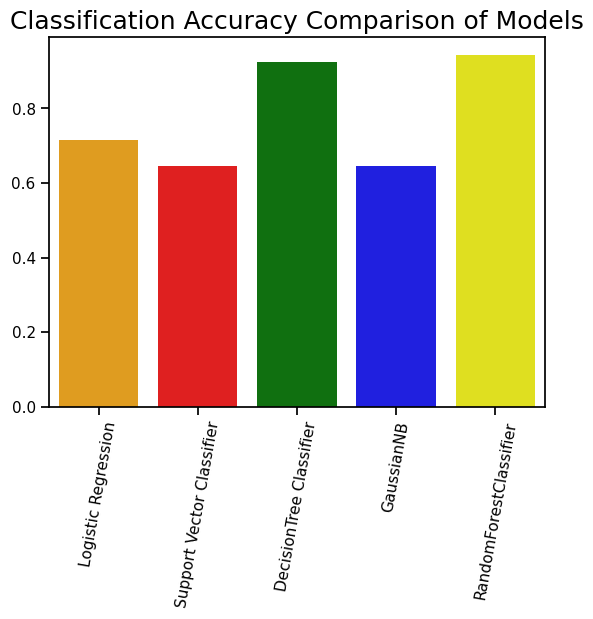

In [50]:
sns.set(context='notebook', style=None)
ax = sns.barplot(x=model_names, y=score, palette=['orange','red','green','blue','yellow'])
ax.set_title('Classification Accuracy Comparison of Models', fontsize=18)
for item in ax.get_xticklabels():
    item.set_rotation(80)
for p in ax.patches:
        ax.annotate('{:}%'.format(p.get_height()), (p.get_x()+0.01, p.get_height()+1))

##**8. MODEL PREDICTION**

In [51]:
model=RandomForestClassifier(max_leaf_nodes=30,n_estimators=25)

In [52]:
model.fit(X_train,Y_train)

RandomForestClassifier(max_leaf_nodes=30, n_estimators=25)

In [53]:
#making a predictive system
input_data=(3,2,3,1,1,1,1,1,1,1,0,1,0)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("The person has no autism.")
else:
    print("The person has autism.")

[0]
The person has no autism.


In [54]:
#making a predictive system
input_data=(6,3,4,1,1,1,1,1,1,1,1,1,0)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("The person has no autism.")
else:
    print("The person has autism.")

[1]
The person has autism.


##**9. SAVE THE MODEL**

In [55]:
import pickle

In [56]:
filename='autism_model.pkl'
pickle.dump(model,open(filename,'wb'))

In [57]:
loaded_model=pickle.load(open("autism_model.pkl",'rb'))

In [58]:
#making a predictive system
input_data=(10,14,3,1,1,1,1,1,1,1,1,1,0)

#changing the input data to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshape the array as we are predicting for one instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=loaded_model.predict(input_data_reshaped)
print(prediction)

if(prediction[0]==0):
    print("The person has no autism.")
else:
    print("The person has autism.")

[0]
The person has no autism.
